# Drugie zajęcia · Onboarding: od danych do pierwszego modelu

Na pierwszych zajęciach poznaliśmy dane i znaleźliśmy w nich rzeczy, które trzeba poprawić, zanim zbudujemy model. Dziś po raz pierwszy przejdziemy przez mały, ale kompletny pipeline ML: od surowych danych, przez przygotowanie i podział, do modelu, jego oceny i Pull Requesta. Liczy się zrozumienie przepływu, a nie ilość kodu. Większość kodu jest gotow, uzupełniasz miejsca, w których trzeba podjąć decyzję.

Nie stroimy dziś hiperparametrów, nie porównujemy wielu modeli i nie robimy walidacji krzyżowej. Jeden baseline, jeden model, jedna uczciwa ocena na zbiorze testowym.

**Na koniec zajęć masz mieć:**

- notebook, który przechodzi bez błędów po *Restart* i *Run All*,
- uzupełnione wszystkie pola *TODO: Twoja odpowiedź*,
- plik `metrics.json` z wynikami obu modeli,
- gałąź `onboarding-model` z commitem `cp2: baseline and model`,
- otwarty Pull Request `onboarding-model` → `main`.

Oznaczenia są takie jak ostatnio: `TODO` to miejsce na Twoją pracę, a w polach na odpowiedź zastępujesz tekst w nawiasie własnymi słowami. Całość zajmie ok. 60–75 minut.

## 0. Zanim zaczniesz: branch i środowisko

Dziś pracujesz na osobnej gałęzi, a nie bezpośrednio na `main`. Zrób to, zanim cokolwiek zmienisz w notebooku. W terminalu, w katalogu repozytorium:

```bash
git switch main
git pull
git switch -c onboarding-model
```

`git pull` pobiera najnowszą wersję `main` z GitHuba, a `git switch -c` tworzy nową gałąź i od razu na nią przechodzi. Sprawdź, gdzie jesteś:

```bash
git branch --show-current
```

Powinno wypisać `onboarding-model`. Potem uruchom komórkę poniżej. Sprawdza, czy notebook działa w środowisku `asi-ml`.

In [26]:
import os
import sys
from pathlib import Path

env_name = Path(sys.prefix).name
conda_env = os.environ.get("CONDA_DEFAULT_ENV", "(nie ustawiono)")

print("Python:           ", sys.version.split()[0])
print("Środowisko:       ", env_name)
print("CONDA_DEFAULT_ENV:", conda_env)

if sys.version_info[:2] != (3, 11) or "asi-ml" not in (env_name, conda_env):
    print("\nUWAGA: to nie jest Python 3.11 ze środowiska asi-ml. Wybierz kernel „Python (asi-ml)”"
          " albo wróć do instrukcji z pierwszych zajęć.")
else:
    print("\nŚrodowisko wygląda poprawnie.")

Python:            3.11.16
Środowisko:        asi-ml
CONDA_DEFAULT_ENV: asi-ml

Środowisko wygląda poprawnie.


## 1. Wczytanie danych i szybki sanity check

Ten sam zbiór i ten sam `DATA_URL` co na pierwszych zajęciach. Notebook wczytuje dane od nowa, więc nie potrzebuje niczego z notebooka 01. Po wczytaniu sprawdź, czy wszystko zgadza się z tym, co już znasz: 7043 wiersze, 21 kolumn, tekstowy typ `TotalCharges` i target z wartościami `No` / `Yes`.

In [27]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
TARGET = "Churn"

pd.set_option("display.max_columns", None)

In [28]:
def load_data(url):
    """Wczytuje zbiór danych z podanego adresu."""
    try:
        return pd.read_csv(url)
    except Exception as error:
        raise RuntimeError(
            "Nie udało się wczytać danych z DATA_URL. Sprawdź połączenie z internetem "
            "i to, czy adres nie został zmieniony. Jeśli problem się powtarza, "
            "zgłoś go w kolejce pomocy i wklej ten komunikat."
        ) from error


df = load_data(DATA_URL)

print("Rozmiar:", df.shape)
print("Typ TotalCharges:", df["TotalCharges"].dtype)
print("Wartości targetu:", sorted(df[TARGET].unique()))

assert df.shape == (7043, 21), "Zbiór ma inny rozmiar niż na pierwszych zajęciach. Sprawdź DATA_URL."

Rozmiar: (7043, 21)
Typ TotalCharges: str
Wartości targetu: ['No', 'Yes']


## 2. Minimalne przygotowanie danych

Pracujemy na kopii `df_model`; surowe `df` zostaje bez zmian. Do poprawienia są dwie rzeczy.

**TotalCharges.** Na pierwszych zajęciach okazało się, że ta kolumna ma typ tekstowy, bo kilka wartości to same białe znaki. `pd.to_numeric(..., errors="coerce")` zamieni tekst na liczby, a wartości, których nie da się odczytać, na braki (`NaN`). Tych wierszy nie usuwamy. Braki uzupełni później imputer w pipeline.

**Target.** Kodujemy `No` → 0 i `Yes` → 1: nie dlatego, że sklearn wymaga liczb, tylko żeby jednoznacznie ustalić klasę pozytywną i mieć jeden, stały kontrakt dla dalszej części workflow. Od teraz **klasa pozytywna 1 oznacza klienta, który odszedł**. Względem niej interpretujemy precision, recall i F1, a w macierzy pomyłek: błędy FP i FN.

In [29]:
df_model = df.copy()

# TODO: zamień TotalCharges na liczby; tekst, którego nie da się odczytać, ma stać się brakiem (NaN).
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"],errors="coerce")

# TODO: zakoduj target: "No" → 0, "Yes" → 1.
# Wskazówka: metoda .map() przyjmuje słownik.
df_model[TARGET] = df_model[TARGET].map({"No": 0, "Yes": 1})

# Sprawdzenie, tej części nie zmieniaj.
assert pd.api.types.is_numeric_dtype(df_model["TotalCharges"]) and df_model["TotalCharges"].notna().any(), (
    "TotalCharges nie jest jeszcze liczbowa. Uzupełnij pierwsze TODO."
)
assert not df_model[TARGET].isna().any() and set(df_model[TARGET].unique()) == {0, 1}, (
    "Target powinien zawierać dokładnie klasy 0 i 1, bez braków. Sprawdź mapowanie No → 0, Yes → 1."
)
print("Braki w TotalCharges po konwersji:", df_model["TotalCharges"].isna().sum())
print("Rozkład targetu:", df_model[TARGET].value_counts().to_dict())

Braki w TotalCharges po konwersji: 11
Rozkład targetu: {0: 5174, 1: 1869}


## 3. X i y

Teraz oddzielamy cechy (`X`) od targetu (`y`). Z cech wypada też identyfikator klienta, który znasz z pierwszych zajęć. Jest inny w każdym wierszu i nic nie mówi o zachowaniu klienta. Model mógłby co najwyżej zapamiętać konkretne osoby, a nowy klient i tak będzie miał nowe ID.

In [30]:
# TODO: wpisz nazwę kolumny, która identyfikuje klienta.
ID_COLUMN = "customerID"

# TODO: X — wszystkie kolumny df_model poza identyfikatorem i targetem; y — sam target.
# Wskazówka: DataFrame.drop(columns=[...]).
X = df_model.drop(columns=[ID_COLUMN,TARGET])
y = df_model[TARGET]

# Sprawdzenie, tej części nie zmieniaj.
assert isinstance(X, pd.DataFrame), "X powinien być DataFrame'em z cechami. Uzupełnij TODO."
assert isinstance(y, pd.Series), "y powinien być jedną kolumną (Series) z targetem. Uzupełnij TODO."
assert TARGET not in X.columns, "Target nie może być jedną z cech w X."
id_like = [column for column in X.columns if X[column].nunique() == len(X)]
assert not id_like, f"Kolumna {id_like} ma inną wartość w każdym wierszu, wygląda na identyfikator."
assert X.shape[1] == df_model.shape[1] - 2, (
    f"X ma {X.shape[1]} kolumn, a powinien mieć wszystkie poza identyfikatorem i targetem."
)
assert len(X) == len(y) == len(df_model), "X i y powinny mieć tyle wierszy, ile df_model."
print("X:", X.shape, "| y:", y.shape)

X: (7043, 19) | y: (7043,)


## 4. Train/test split

Dzielimy dane raz: 80% do uczenia, 20% do końcowej oceny. Zbiór testowy odkładamy na bok i używamy go tylko do oceny dwóch modeli ustalonych z góry: baseline'u i regresji logistycznej. Niczego na nim nie stroimy.

Użyj `test_size=0.2`, `random_state=42` i `stratify=y`.

Dzielimy dane **przed** dopasowaniem preprocessingu. Gdyby imputer albo scaler uczyły się na całym zbiorze, ich statystyki (mediana, średnia, odchylenie standardowe) korzystałyby z danych testowych. To byłby data leakage: zbiór testowy przestałby być niezależną oceną, a wynik mógłby wyjść zbyt optymistycznie.

In [31]:
# TODO: uzupełnij trzy parametry podziału.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Sprawdzenie, tej części nie zmieniaj.
expected_test_rows = math.ceil(0.2 * len(X))
assert len(X_test) == expected_test_rows, (
    f"Zbiór testowy ma {len(X_test)} wierszy, a przy test_size=0.2 powinien mieć {expected_test_rows}."
)
reference_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)[1]
assert X_test.index.equals(reference_test.index), "Podział różni się od ustalonego. Sprawdź random_state i stratify."

print(f"Train: {len(X_train)} wierszy, test: {len(X_test)} wierszy")
print(f"Odsetek Churn = 1 w train: {y_train.mean():.3f}")
print(f"Odsetek Churn = 1 w test:  {y_test.mean():.3f}")

Train: 5634 wierszy, test: 1409 wierszy
Odsetek Churn = 1 w train: 0.265
Odsetek Churn = 1 w test:  0.265


**TODO: Twoja odpowiedź** (1–2 zdania): po co użyliśmy `stratify=y`? Porównaj odsetek Churn = 1 w train i test.

*Użyliśmy `stratify=y` żeby zachować podobną proporcje w train i test setach. Odsetki Churn = 1 są równe.*

## 5. Kolumny numeryczne i kategoryczne

Liczby i kategorie przygotujemy inaczej, więc trzeba je rozdzielić. Listę kolumn numerycznych tworzysz Ty, kategoryczne to wszystkie pozostałe. Kieruj się znaczeniem kolumny, a nie tylko typem w pandas. Tak jak na pierwszych zajęciach. Kolumna zapisana jako 0/1 może sensownie trafić do każdej z grup; zdecyduj, gdzie ją umieścić.

In [32]:
# TODO: wpisz nazwy kolumn, które opisują wielkości liczbowe.
numeric_features = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]

# Kategoryczne to wszystkie pozostałe kolumny X.
categorical_features = [column for column in X.columns if column not in numeric_features]

print("Numeryczne:  ", numeric_features)
print("Kategoryczne:", categorical_features)

# Sprawdzenie, tej części nie zmieniaj.
assert numeric_features, "Lista numeric_features jest pusta. Uzupełnij TODO."
unknown = [column for column in numeric_features if column not in X.columns]
assert not unknown, f"Tych kolumn nie ma w X: {unknown}. Sprawdź pisownię."
not_numeric = [column for column in numeric_features if not pd.api.types.is_numeric_dtype(X[column])]
assert not not_numeric, f"Te kolumny nie są liczbowe: {not_numeric}. Czy przygotowanie danych w sekcji 2 się udało?"
suspicious = [
    column for column in categorical_features
    if pd.api.types.is_numeric_dtype(X[column]) and X[column].nunique() > 20
]
assert not suspicious, (
    f"Kolumny {suspicious} są liczbowe i mają wiele różnych wartości, a trafiły do kategorycznych. "
    "Czy to na pewno kategorie?"
)

Numeryczne:   ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Kategoryczne: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Preprocessing
Każda grupa kolumn dostaje własny mały pipeline:

- **numeryczne:** brakujące wartości uzupełniamy medianą, a potem skalujemy (`StandardScaler`), bo cechy mają bardzo różne skal jak miesiące stażu i sumy opłat, a regresja logistyczna uczy się stabilniej na porównywalnych wartościach;
- **kategoryczne:** braki uzupełniamy najczęstszą wartością, a kategorie zamieniamy na kolumny 0/1 (`OneHotEncoder`).

`ColumnTransformer` łączy oba pipeline'y i kieruje do każdego jego kolumny. Na razie nic nie jest dopasowywane. Budujemy przepis. Uczenie nastąpi dopiero razem z modelem, na `X_train`.

In [33]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# TODO: wstaw właściwą listę kolumn w miejsce [] w obu wierszach.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

# Sprawdzenie, tej części nie zmieniaj.
assigned = {name: set(columns) for name, _, columns in preprocessor.transformers}
assert assigned["numeric"] == set(numeric_features) and assigned["categorical"] == set(categorical_features), (
    "Przypisanie kolumn się nie zgadza. Który pipeline jest dla liczb, a który dla kategorii?"
)

**TODO: Twoja odpowiedź** (1–3 zdania na pytanie):

1. Po co są dwa osobne pipeline'y zamiast jednego dla wszystkich kolumn?

*Bo kolumny liczbowe i kategoryczne wymagają różnych operacji. *

2. Do czego przydaje się `handle_unknown="ignore"` w `OneHotEncoder`?

*To pozwala obsłużyć kategorię, której nie było w danych treningowych, bez zgłaszania błędu.*

## 7. Baseline

Zanim ocenimy właściwy model, potrzebujemy punktu odniesienia. `DummyClassifier(strategy="most_frequent")` zawsze przewiduje najczęstszą klasę i w ogóle nie patrzy na cechy, więc nie potrzebuje preprocessingu. To nie jest „zły model”, tylko punkt odniesienia: pokazuje, ile da się osiągnąć bez żadnej wiedzy o kliencie. Jeśli właściwy model nie poprawia metryk istotnych dla naszego celu, nie mamy dowodu, że wnosi coś ponad trywialną strategię.

Na pierwszych zajęciach szacowaliśmy accuracy takiego „modelu” na ok. 73%. Porównaj ten szacunek z wynikiem poniżej.

In [34]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline przewiduje klasy:", sorted(set(baseline_pred.tolist())))
print(f"Accuracy baseline'u na zbiorze testowym: {accuracy_score(y_test, baseline_pred):.3f}")

Baseline przewiduje klasy: [0]
Accuracy baseline'u na zbiorze testowym: 0.735


## 8. Logistic Regression

Teraz właściwy model: regresja logistyczna, `LogisticRegression(max_iter=1000)`. Preprocessing i klasyfikator łączymy w jeden `Pipeline`, `fit` uczy oba kroki na danych treningowych, a `predict` stosuje je do nowych danych.

In [35]:
# TODO: w miejsce None wstaw klasyfikator: regresję logistyczną z max_iter=1000.
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

# Sprawdzenie, tej części nie zmieniaj.
assert isinstance(model.named_steps["classifier"], LogisticRegression), (
    "Krok classifier powinien być regresją logistyczną. Uzupełnij TODO."
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [36]:
# TODO: dopasuj model na danych treningowych.
model.fit(X_train, y_train)

# TODO: policz predykcje dla zbioru testowego.
y_pred = model.predict(X_test)

# Sprawdzenie, tej części nie zmieniaj.
assert y_pred is not None and len(y_pred) == len(y_test), (
    "y_pred powinno zawierać predykcję dla każdego wiersza X_test. Uzupełnij TODO."
)

**TODO: Twoja odpowiedź** (1–3 zdania na pytanie):

1. Co byłoby nie tak, gdyby imputer policzył medianę `TotalCharges` na całym zbiorze, jeszcze przed `train_test_split`? Jakiej informacji ze zbioru testowego użyłby wtedy preprocessing?

*Mediana byłaby policzona też z wartości TotalCharges ze zbioru testowego. Czyli użylibyśmy danych testowych do przygotowania treningu, chociaż powinny służyć tylko do sprawdzenia modelu.*

2. Co daje nam Pipeline w porównaniu z ręcznym wykonywaniem kolejnych transformacji?

*Wykonuje wszystkie kroki po kolei i zmniejsza ryzyko pomyłki. Uczy transformacje na danych treningowych, a potem stosuje je do testowych bez ponownego dopasowania.*

## 9. Porównanie wyników

Liczymy cztery metryki dla obu modeli. Precision, recall i F1 dotyczą klasy pozytywnej, czyli **1 = klient odszedł**:

- **precision** - jaka część klientów, których model wskazał jako odchodzących, naprawdę odeszła;
- **recall** - jaką część klientów, którzy naprawdę odeszli, model wskazał;
- **F1** - jedna liczba łącząca precision i recall (ich średnia harmoniczna).

Baseline nigdy nie przewiduje klasy 1, więc jego precision wymagałaby dzielenia przez zero. Ustawiamy `zero_division=0`: zamiast ostrzeżenia dostajemy 0, co uczciwie opisuje model, który nie wskazał ani jednego odchodzącego klienta.

In [37]:
def evaluate(name, y_true, y_predicted):
    """Zwraca accuracy oraz precision, recall i F1 dla klasy 1 (klient odszedł)."""
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_predicted),
        "precision": precision_score(y_true, y_predicted, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_predicted, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_predicted, pos_label=1, zero_division=0),
    }


results = pd.DataFrame(
    [
        evaluate("baseline (most_frequent)", y_test, baseline_pred),
        evaluate("LogisticRegression", y_test, y_pred),
    ]
).set_index("model")

results.round(3)

,accuracy,precision,recall,f1
model,,,,
baseline (most_frequent),0.735,0.000,0.000,0.000
LogisticRegression,0.806,0.657,0.559,0.604


Wyniki zapisujemy też do pliku `metrics.json` w katalogu głównym repozytorium. To prosty, maszynowo czytelny artefakt eksperymentu: trafia do commita razem z notebookiem i można go później porównywać albo sprawdzać automatycznie. Helper `save_metrics` przygotowuje plik za Ciebie. Wystarczy go wywołać.

In [38]:
METRIC_NAMES = ["accuracy", "precision", "recall", "f1"]
MODEL_KEYS = {"baseline (most_frequent)": "dummy", "LogisticRegression": "logistic_regression"}


def find_repo_root():
    """Zwraca katalog główny repozytorium, czyli pierwszy katalog w górę, który zawiera .git."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


# Notebook działa zwykle w katalogu notebooks/, a plik ma trafić do katalogu głównego repozytorium.
METRICS_PATH = find_repo_root() / "metrics.json"


def save_metrics(results, path=METRICS_PATH):
    """Zapisuje metryki obu modeli do pliku JSON jako zwykłe liczby i zwraca zapisany słownik."""
    metrics = {
        key: {metric: float(results.loc[name, metric]) for metric in METRIC_NAMES}
        for name, key in MODEL_KEYS.items()
    }
    Path(path).write_text(json.dumps(metrics, indent=2) + "\n", encoding="utf-8")
    print("Zapisano", os.path.relpath(path))
    return metrics


# TODO: zapisz wyniki obu modeli, wywołując save_metrics z tabelą results.
save_metrics(results)

Zapisano ..\metrics.json


{'dummy': {'accuracy': 0.7345635202271115,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 'logistic_regression': {'accuracy': 0.8055358410220014,
  'precision': 0.6572327044025157,
  'recall': 0.5588235294117647,
  'f1': 0.6040462427745664}}

Nie ma jednej metryki, która zawsze jest najważniejsza. Wybór zależy od tego, ile kosztują poszczególne błędy i do czego model ma służyć.

**TODO: Twoja odpowiedź** (1–3 zdania na pytanie):

1. Czy model LogisticRegression jest lepszy od baseline'u? Na jakiej podstawie?

*Tak, LogisticRegresion jest lepszy na podstawie accuracy i tylko bo baseline nie przewiduje '1' i z tego powodu nie możemy otrzymać inne metryki.*

2. Dlaczego samo accuracy nie wystarcza w tym problemie?

*Bo można mieć wysoką accuracy, mimo że model nie wykrywa klientów, którzy odchodzą. Na przykład dummy ma 73,5% accuracy, ale zawsze przewiduje '0' i nie wykrywa żadnego odejścia.*

3. Co oznacza recall dla klasy Churn = 1 w kontekście biznesowym?

*Recall pokazuje, jaką część odchodzących klientów model wykrywa.*

## 10. Confusion matrix i błędy modelu

Macierz pomyłek pokazuje, gdzie dokładnie model się myli. Wiersze to klasy prawdziwe, kolumny przewidziane:

- **TN**: prawdziwe 0, przewidziane 0;
- **FP**: prawdziwe 0, przewidziane 1;
- **FN**: prawdziwe 1, przewidziane 0;
- **TP**: prawdziwe 1, przewidziane 1.

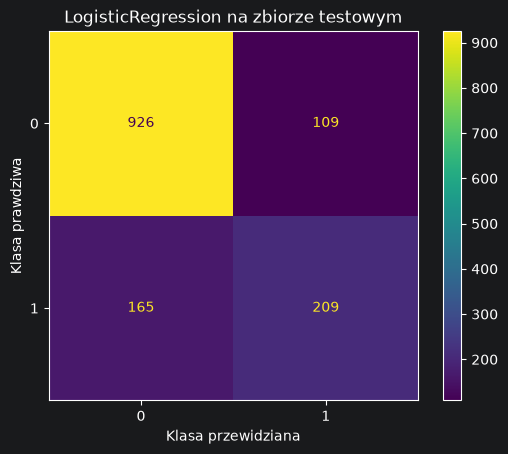

In [39]:
matrix_plot = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
matrix_plot.ax_.set_xlabel("Klasa przewidziana")
matrix_plot.ax_.set_ylabel("Klasa prawdziwa")
matrix_plot.ax_.set_title("LogisticRegression na zbiorze testowym")
plt.show()

In [40]:
# TODO: odczytaj z macierzy liczbę false negatives (FN) i wpisz ją jako liczbę.
false_negatives = 165

# Sprawdzenie, tej części nie zmieniaj.
assert false_negatives == int(((y_test.to_numpy() == 1) & (np.asarray(y_pred) == 0)).sum()), (
    "To nie jest liczba FN. Znajdź wiersz z prawdziwą klasą 1 i kolumnę z przewidzianą klasą 0."
)

**TODO: Twoja odpowiedź** (1–3 zdania): co oznacza false negative w tym problemie? Opisz to słowami o klientach, a nie o klasach 0 i 1.

*Model przewidział, że klient zostanie, ale klient faktycznie odszedł.*

## 11. Checkpoint i Pull Request

Komórka poniżej sprawdza to, co da się sprawdzić automatycznie. Nie ocenia Twoich odpowiedzi i nie wymaga konkretnego wyniku. Sprawdza, czy przepływ jest kompletny i poprawny.

In [41]:
REQUIRED_NUMERIC = ["tenure", "MonthlyCharges", "TotalCharges"]
problems = []


def check(condition, message):
    try:
        passed = bool(condition())
    except (AttributeError, KeyError, NameError, OSError, TypeError, ValueError):
        passed = False
    if not passed:
        problems.append(message)
    return passed


needed = ["df_model", "X", "y", "X_train", "X_test", "y_test", "numeric_features", "model", "y_pred",
          "results", "false_negatives", "METRIC_NAMES", "MODEL_KEYS", "METRICS_PATH"]
missing = [name for name in needed if name not in globals()]
assert not missing, f"Brakuje: {', '.join(missing)}. Uruchom notebook od początku (Restart, Run All)."

check(lambda: not y.isna().any() and set(y.unique()) == {0, 1},
      "Target powinien zawierać dokładnie klasy 0 i 1, bez braków. Sprawdź mapowanie Churn w sekcji 2.")
check(lambda: "customerID" not in X.columns, "customerID nie może być cechą; usuń go z X (sekcja 3).")
check(lambda: len(X_train) > 0 and len(X_test) > 0, "Zbiory train i test nie mogą być puste (sekcja 4).")
check(lambda: len(X_train) + len(X_test) == len(X), "Train i test razem powinny mieć tyle wierszy, ile X (sekcja 4).")
check(lambda: set(REQUIRED_NUMERIC) <= set(numeric_features),
      "tenure, MonthlyCharges i TotalCharges opisują wielkości liczbowe i powinny być w numeric_features (sekcja 5).")

model_ok = check(
    lambda: isinstance(model, Pipeline)
    and list(model.named_steps) == ["preprocessor", "classifier"]
    and isinstance(model.named_steps["classifier"], LogisticRegression),
    "model powinien być Pipeline'em z krokami preprocessor i classifier (LogisticRegression), sekcja 8.",
)
if model_ok and check(
    lambda: hasattr(model.named_steps["classifier"], "coef_")
    and hasattr(model.named_steps["preprocessor"], "transformers_"),
    "Model albo preprocessor nie jest dopasowany. Wywołaj fit na X_train i y_train (sekcja 8).",
):
    # Preprocessing ma być uczony tylko na X_train; inaczej mamy leakage.
    def numeric_step(name):
        return model.named_steps["preprocessor"].named_transformers_["numeric"].named_steps[name]

    scaler_found = check(lambda: hasattr(numeric_step("scaler"), "n_samples_seen_"),
                         "Nie widać dopasowanego scalera w preprocessingu (sekcje 6 i 8).")
    if scaler_found and check(
        lambda: np.all(np.asarray(numeric_step("scaler").n_samples_seen_) == len(X_train)),
        "Preprocessing wygląda na dopasowany na danych innych niż X_train. Sprawdź kolejność split → fit (sekcje 4 i 8).",
    ):
        # Kontrola dodatkowa: mediany imputera mają pochodzić z X_train.
        check(lambda: np.allclose(numeric_step("imputer").statistics_,
                                  X_train[list(numeric_step("imputer").feature_names_in_)].median().to_numpy()),
              "Mediany imputera nie pochodzą z X_train. Sprawdź, na jakich danych wywołujesz fit (sekcja 8).")
predictions_ok = check(lambda: y_pred is not None and len(y_pred) == len(y_test),
                       "Brakuje predykcji dla każdego wiersza X_test (sekcja 8).")
results_ok = check(lambda: set(MODEL_KEYS) <= set(results.index)
                   and results.loc[list(MODEL_KEYS), METRIC_NAMES].apply(lambda column: column.between(0, 1)).all().all(),
                   "Tabela results powinna mieć metryki obu modeli w zakresie [0, 1] (sekcja 9).")
if predictions_ok:
    check(lambda: false_negatives == int(((y_test.to_numpy() == 1) & (np.asarray(y_pred) == 0)).sum()),
          "Liczba false negatives nie zgadza się z macierzą pomyłek (sekcja 10).")

saved = None

metrics_exists = check(
    lambda: METRICS_PATH.exists(),
    "Nie ma pliku metrics.json. Wywołaj save_metrics w sekcji 9."
)

metrics_is_valid = False

if metrics_exists:
    metrics_is_valid = check(
        lambda: isinstance(
            json.loads(METRICS_PATH.read_text(encoding="utf-8")),
            dict,
        ),
        "metrics.json nie jest poprawnym plikiem JSON. Wywołaj ponownie save_metrics (sekcja 9).",
    )

if metrics_is_valid:
    saved = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
if saved is not None and check(
    lambda: all(isinstance(saved[key][metric], (int, float)) and 0 <= saved[key][metric] <= 1
                for key in MODEL_KEYS.values() for metric in METRIC_NAMES),
    "metrics.json powinien zawierać dummy i logistic_regression z accuracy, precision, recall i f1 (sekcja 9).",
) and results_ok:
    check(lambda: all(abs(saved[key][metric] - results.loc[name, metric]) < 1e-9
                      for name, key in MODEL_KEYS.items() for metric in METRIC_NAMES),
          "metrics.json nie odpowiada bieżącym wynikom; wywołaj ponownie save_metrics (sekcja 9).")

assert not problems, "Checkpoint niezaliczony:\n- " + "\n- ".join(problems)
print("Checkpoint zaliczony.")

Checkpoint zaliczony.


Gdy checkpoint przejdzie, zapisz pracę i otwórz Pull Request.

1. Uruchom notebook od czystego kernela: w VS Code kliknij **Restart**, a potem **Run All** (w JupyterLab: *Kernel → Restart Kernel and Run All Cells*). Tylko tak wiesz, że notebook działa od początku do końca i nie korzysta ze zmiennych, które zostały w pamięci po wcześniejszych próbach. Wszystkie komórki powinny przejść, a checkpoint wypisać „Checkpoint zaliczony.” Potem zapisz notebook.
2. Wyszukaj (Ctrl+F) tekst „(odpowiedź)”. Nie powinien zostać w żadnym polu na odpowiedź.
3. Zrób commit z notebookiem i plikiem `metrics.json`, który podczas Run All powstał w katalogu głównym repozytorium, i wypchnij gałąź:

   ```bash
   git status
   git add notebooks/02_onboarding_model.ipynb metrics.json
   git commit -m "cp2: baseline and model"
   git push -u origin onboarding-model
   ```

   Przy commicie mogą uruchomić się hooki pre-commit, np. ruff albo nbstripout. Jeśli commit zatrzyma się z komunikatem, że hook zmodyfikował pliki, nic się nie zepsuło: hook poprawił formatowanie albo usunął outputy z notebooka i tak ma być. Dodaj zmiany i powtórz commit:

   ```bash
   git add .
   git commit -m "cp2: baseline and model"
   ```

   Jeśli hook zgłasza błąd, którego nie poprawił automatycznie, przeczytaj komunikat. Zwykle wskazuje konkretną linię.

4. Utwórz Pull Request z `onboarding-model` do `main`. Po `git push` GitHub zwykle podaje gotowy link w terminalu albo na stronie repozytorium. Dodaj krótki opis zmian. Nie scalaj PR-a, zostaw go do sprawdzenia.

Jeśli w repozytorium działają automatyczne checki, na stronie PR zobaczysz, czy przeszły.